# 05c — Model Training: CNN + CNN-BiLSTM Averaging Ensemble

| Field | Detail |
|---|---|
| **Notebook** | `05c_model_ensemble.ipynb` |
| **Pipeline stage** | H1 — Voice Emotion Recognition - 5 of 7 (Model Training, candidate 3 of 4) |
| **Owner(s)** | *Thrithwaka Preethi Shakya* |
| **Created** | *28/08/2026* |
| **Last updated** | *28/08/2026* |
| **Upstream dependency** | `04a_feature_extraction_handcrafted.ipynb` (Feature Set B: MFCC + RMSE + ZCR + Chroma STFT, flattened; and class weights) |
| **Downstream dependency** | `06_model_selection.ipynb` |
| **Runs on** | Local machine, or **Google Colab** with the project folder mounted via Google Drive (see Section 0) |
| **Literature reference** | Chowdhury, Ramanna & Kotecha (2025), *Speech emotion recognition with light weight deep neural ensemble model using hand crafted features*, Scientific Reports |

## Purpose

Chowdhury et al. (2025)'s "ensemble" is not a single combined architecture — it is **two independently-trained models whose predicted probabilities are averaged**: a plain 1D CNN, and a CNN with a Bi-LSTM layer inserted partway through, both sharing an otherwise identical convolutional backbone. Their own Fig. 1 shows exactly this: two parallel branches producing $P_1(t)$ (CNN) and $P_2(t)$ (CNN-BiLSTM), combined through an "averaging unit" into the final prediction $P(t)$. This notebook replicates that structure directly: it trains both branches independently, evaluates each on its own, and then evaluates the averaged ensemble — reporting all three, so we can verify empirically (as they did) whether averaging actually helps on our own data, rather than assuming it does.

### A note on what's faithfully replicated vs. what's a documented design decision

- **Faithfully replicated:** the 5-layer Conv1D backbone (filter progression 128 \u2192 128 \u2192 64 \u2192 64 \u2192 32), kernel sizes (5 for the first three layers, 3 for the last two), the position of the Bi-LSTM (inserted after the 4th conv block, before the 5th), dropout placement (after the 2nd, 4th, and 5th blocks) and rate (20%), and the training hyperparameters in their Table 3 (batch size 64, Adam at 0.001, LR reduction factor 0.5 with patience 3, early stopping patience 5, minimum LR 1e-5) — all taken directly from their paper.
- **A deliberate deviation, documented here:** we monitor **validation loss** for checkpointing and early stopping, not validation accuracy as they did, to keep the training protocol identical across *all four* of this project's H1 candidate models — internal consistency across our own model-selection comparison takes priority over matching this one paper's monitoring metric exactly.
- **An architectural quirk inherited from the paper, worth flagging for the thesis discussion:** Feature Set B concatenates four different feature types (ZCR, RMSE, MFCC, Chroma) end-to-end into one flat vector before feeding it to a 1D CNN — meaning the network is asked to treat the *boundary* between, say, the MFCC segment and the Chroma segment as if it were simply more time passing. This is an unusual design choice, but it is exactly what Chowdhury et al. describe doing, so it is replicated here rather than "corrected," specifically so our results are comparable to theirs. It is worth naming explicitly as a limitation, not silently accepting it as obviously correct.

## Objectives

1. Load and validate Feature Set B and class weights from `04a`.
2. Fit a feature scaler on the training split only (Feature Set B mixes several feature types with very different natural ranges, making scaling more important here than for any other H1 candidate).
3. Define the CNN and CNN-BiLSTM branches, matching Chowdhury et al. (2025)'s architecture exactly, with dynamically-computed layer dimensions (since our concatenated feature length differs from theirs).
4. Train both branches independently.
5. Evaluate each branch individually, then evaluate the averaged-probability ensemble, and compare all three.
6. Save both trained models, the scaler, comparison figures, and full run metadata.
7. Append results to the shared cross-model experiment log — the ensemble result is this notebook's official H1 candidate entry; the two individual branches are logged as supporting diagnostic detail.
8. Leave a structured handoff note.

## 0. Environment Setup

### 0.1 Google Colab / Google Drive Setup

Same auto-detecting pattern as `05a` and `05b` — mounts Drive if on Colab, falls back to local path resolution otherwise. Edit `PROJECT_ROOT` below if your Drive folder path differs from `MyDrive/emotion-ai-companion-research`.

**Recommended Colab runtime:** `Runtime` \u2192 `Change runtime type` \u2192 **T4 GPU**.

In [1]:
import sys
import os
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    PROJECT_ROOT = Path("/content/drive/MyDrive/emotion-ai-companion-research")

    if not PROJECT_ROOT.exists():
        raise FileNotFoundError(
            f"{PROJECT_ROOT} not found. Check that this path matches your Google Drive folder "
            "exactly (case-sensitive), and that the cell above finished mounting successfully."
        )

    os.chdir(PROJECT_ROOT)
    print(f"\u2705 Running on Google Colab. Project root set to: {PROJECT_ROOT}")

else:
    PROJECT_ROOT = Path.cwd()
    while not (PROJECT_ROOT / "config").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
        PROJECT_ROOT = PROJECT_ROOT.parent
    print(f"Running locally. Project root resolved to: {PROJECT_ROOT}")

sys.path.insert(0, str(PROJECT_ROOT))

Mounted at /content/drive
✅ Running on Google Colab. Project root set to: /content/drive/MyDrive/emotion-ai-companion-research


In [2]:
if IN_COLAB:
    print("Installing project-specific dependencies not pre-installed on Colab...")
    !pip install -q pydantic-settings==2.4.0
    print("Done.")
else:
    print("Running locally — skipping Colab-specific dependency installation.")

Installing project-specific dependencies not pre-installed on Colab...
Done.


In [3]:
import json
import time
import logging
import subprocess
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
)

from config.settings import settings  # noqa: E402

sns.set_theme(style="whitegrid")

In [4]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cpu":
    print("\u26a0\ufe0f  No GPU detected. If on Colab, go to Runtime \u2192 Change runtime type \u2192 "
          "T4 GPU, then re-run this notebook from the top. This notebook trains TWO models, so a "
          "GPU matters even more here than in 05a/05b.")

Using device: cuda


In [5]:
LOG_DIR = PROJECT_ROOT / "reports" / "logs"
LOG_DIR.mkdir(parents=True, exist_ok=True)
LOG_PATH = LOG_DIR / "05c_model_ensemble.log"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.FileHandler(LOG_PATH, mode="w"), logging.StreamHandler(sys.stdout)],
)
logger = logging.getLogger("model_ensemble")
logger.info("Environment: %s", "Google Colab" if IN_COLAB else "local")

## 1. Load & Validate Upstream Outputs

Loads Feature Set B specifically (`X_set_b`) — the flattened, concatenated vector — not Feature Set A, which belongs to `05b`'s CNN-LSTM.

In [6]:
handcrafted_npz_path = PROJECT_ROOT / "data" / "processed" / "features" / "h1_handcrafted_features.npz"
handcrafted_metadata_path = PROJECT_ROOT / "data" / "processed" / "features" / "h1_handcrafted_features_metadata.json"

for path in (handcrafted_npz_path, handcrafted_metadata_path):
    if not path.exists():
        raise FileNotFoundError(f"{path} not found. Run 04a_feature_extraction_handcrafted.ipynb first.")

with open(handcrafted_metadata_path) as f:
    handcrafted_metadata = json.load(f)

assert handcrafted_metadata["total_files_failed"] == 0, "04a reported extraction failures — resolve before training."

label_to_idx = {k: int(v) for k, v in handcrafted_metadata["label_to_idx"].items()}
idx_to_label = {int(k): v for k, v in handcrafted_metadata["idx_to_label"].items()}
NUM_CLASSES = len(label_to_idx)

logger.info("Upstream validated. %d classes.", NUM_CLASSES)
print(f"\u2705 Upstream validated. {NUM_CLASSES} classes: {list(label_to_idx.keys())}")

✅ Upstream validated. 6 classes: ['happy', 'sad', 'angry', 'fear', 'neutral', 'surprise']


In [7]:
data = np.load(handcrafted_npz_path, allow_pickle=True)
X_set_b, y, split = data["X_set_b"], data["y"], data["split"]

print(f"X_set_b shape: {X_set_b.shape}  (N, D)")
print(f"Split sizes: {pd.Series(split).value_counts().to_dict()}")

D = X_set_b.shape[1]
assert D == handcrafted_metadata["feature_set_b"]["length"]
print(f"Flattened feature vector length D={D} (ZCR + RMSE + flattened MFCC + flattened Chroma)")

X_set_b shape: (4068, 4266)  (N, D)
Split sizes: {'train': 3254, 'val': 407, 'test': 407}
Flattened feature vector length D=4266 (ZCR + RMSE + flattened MFCC + flattened Chroma)


## 2. Feature Scaling — Fit on Training Split Only

Feature Set B concatenates four feature types with very different natural scales (Chroma and ZCR are roughly bounded in `[0, 1]`; MFCC and RMSE are not) — without scaling, gradients would be dominated by whichever feature type happens to have the largest raw magnitude, regardless of its actual relevance to emotion. A `StandardScaler` is fit on the training split only and applied identically to validation and test, and saved for future reuse.

In [8]:
train_mask, val_mask, test_mask = split == "train", split == "val", split == "test"

scaler = StandardScaler()
scaler.fit(X_set_b[train_mask])

X_train = scaler.transform(X_set_b[train_mask]).astype(np.float32)
X_val = scaler.transform(X_set_b[val_mask]).astype(np.float32)
X_test = scaler.transform(X_set_b[test_mask]).astype(np.float32)
y_train, y_val, y_test = y[train_mask], y[val_mask], y[test_mask]

print(f"Scaler fit on {len(X_train)} training examples.")
print(f"Post-scaling train mean (should be \u2248 0): {X_train.mean():.4f}, std (should be \u2248 1): {X_train.std():.4f}")

Scaler fit on 3254 training examples.
Post-scaling train mean (should be ≈ 0): -0.0000, std (should be ≈ 1): 1.0000


## 3. Configuration

Hyperparameters here match Chowdhury et al. (2025)'s Table 3 exactly, including a batch size of 64 — larger than the 32 used in `05a`/`05b`. This deliberately follows the source paper's specified value rather than forcing artificial consistency with this project's other notebooks; hyperparameters are properly tuned per architecture, and matching the paper we're replicating takes priority here.

In [9]:
BATCH_SIZE = 64          # Table 3, Chowdhury et al. (2025)
MAX_EPOCHS = 100
LEARNING_RATE = 1e-3
LR_SCHEDULER_PATIENCE = 3
LR_SCHEDULER_FACTOR = 0.5
LR_MIN = 1e-5            # explicit minimum LR floor, per Table 3
EARLY_STOPPING_PATIENCE = 5
DROPOUT_RATE = 0.20      # Table 3 — note: 20%, not 25% as used for the raw-CNN candidate in 05a
LSTM_HIDDEN_SIZE = 64    # bidirectional -> 128-channel output, matching Table 2's Bi-LSTM output shape
WEIGHT_DECAY = 1e-4

MODEL_DIR = PROJECT_ROOT / "models" / "h1"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
CNN_MODEL_PATH = MODEL_DIR / "ensemble_cnn_branch.pt"
CNN_BILSTM_MODEL_PATH = MODEL_DIR / "ensemble_cnn_bilstm_branch.pt"
SCALER_PATH = MODEL_DIR / "ensemble_scaler.pkl"
MODEL_METADATA_PATH = MODEL_DIR / "ensemble_metadata.json"

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "h1_models"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

EXPERIMENT_LOG_PATH = PROJECT_ROOT / "reports" / "experiment_log.csv"

joblib.dump(scaler, SCALER_PATH)
logger.info("Saved fitted scaler to %s", SCALER_PATH)
print(f"Scaler saved: {SCALER_PATH}")

Scaler saved: /content/drive/MyDrive/emotion-ai-companion-research/models/h1/ensemble_scaler.pkl


## 4. Dataset and DataLoaders

In [10]:
class FlatVectorDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X).float().unsqueeze(1)  # (N, 1, D) — single input channel for Conv1d
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = FlatVectorDataset(X_train, y_train)
val_dataset = FlatVectorDataset(X_val, y_val)
test_dataset = FlatVectorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=torch.Generator().manual_seed(RANDOM_SEED))
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 3254 | Val: 407 | Test: 407


In [11]:
class_weights_by_label = handcrafted_metadata["class_weights"]
class_weights_tensor = torch.tensor(
    [class_weights_by_label[idx_to_label[i]] for i in range(NUM_CLASSES)],
    dtype=torch.float32,
).to(DEVICE)

print("Class weights (reused from 04a) in label-index order:")
for i in range(NUM_CLASSES):
    print(f"  {i} ({idx_to_label[i]}): {class_weights_tensor[i].item():.4f}")

Class weights (reused from 04a) in label-index order:
  0 (happy): 1.0409
  1 (sad): 1.0390
  2 (angry): 1.0390
  3 (fear): 1.0390
  4 (neutral): 0.8395
  5 (surprise): 1.0409


## 5. Model Definitions

Both branches share an identical 4-block Conv1D backbone (filters 128 \u2192 128 \u2192 64 \u2192 64, kernel sizes 5-5-5-3, dropout after blocks 2 and 4). The **CNN-BiLSTM branch** inserts a bidirectional LSTM after block 4; the **plain CNN branch** skips straight to block 5. Both then apply a final 5th conv block (32 filters, kernel 3, dropout), flatten, and pass through the same dense classifier head (128 units \u2192 num_classes). Because our concatenated Feature Set B length differs from Chowdhury et al.'s, the flattened dimension feeding the dense head is **computed dynamically** via a dummy forward pass, rather than hardcoded to their paper-specific value.

In [12]:
def shared_conv_backbone(dropout: float = DROPOUT_RATE) -> nn.Sequential:
    """The 4-block Conv1D backbone shared by both branches, per Chowdhury et al. (2025), Table 2."""
    return nn.Sequential(
        nn.Conv1d(1, 128, kernel_size=5, padding=2),
        nn.BatchNorm1d(128),
        nn.ReLU(inplace=True),
        nn.MaxPool1d(2),

        nn.Conv1d(128, 128, kernel_size=5, padding=2),
        nn.BatchNorm1d(128),
        nn.ReLU(inplace=True),
        nn.MaxPool1d(2),
        nn.Dropout(dropout),

        nn.Conv1d(128, 64, kernel_size=5, padding=2),
        nn.BatchNorm1d(64),
        nn.ReLU(inplace=True),
        nn.MaxPool1d(2),

        nn.Conv1d(64, 64, kernel_size=3, padding=1),
        nn.BatchNorm1d(64),
        nn.ReLU(inplace=True),
        nn.MaxPool1d(2),
        nn.Dropout(dropout),
    )


def final_conv_block(in_channels: int, dropout: float = DROPOUT_RATE) -> nn.Sequential:
    """The 5th and final conv block, applied after the backbone (and after the LSTM, for that branch)."""
    return nn.Sequential(
        nn.Conv1d(in_channels, 32, kernel_size=3, padding=1),
        nn.BatchNorm1d(32),
        nn.ReLU(inplace=True),
        nn.MaxPool1d(2),
        nn.Dropout(dropout),
    )

In [13]:
class EnsembleCNN(nn.Module):
    """Plain CNN branch — identical backbone to the CNN-BiLSTM branch, minus the LSTM layer."""

    def __init__(self, num_classes: int, input_length: int, dropout: float = DROPOUT_RATE):
        super().__init__()
        self.backbone = shared_conv_backbone(dropout)
        self.final_conv = final_conv_block(in_channels=64, dropout=dropout)

        flatten_dim = self._compute_flatten_dim(input_length)
        self.classifier = nn.Sequential(
            nn.Linear(flatten_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes),
        )

    def _compute_flatten_dim(self, input_length: int) -> int:
        with torch.no_grad():
            dummy = torch.zeros(2, 1, input_length)
            out = self.final_conv(self.backbone(dummy))
            return out.view(2, -1).shape[1]

    def forward(self, x):
        x = self.backbone(x)
        x = self.final_conv(x)
        x = x.flatten(start_dim=1)
        return self.classifier(x)

In [14]:
class EnsembleCNNBiLSTM(nn.Module):
    """CNN-BiLSTM branch — identical backbone, with a Bi-LSTM inserted after block 4 (Chowdhury et al., Table 2)."""

    def __init__(
        self, num_classes: int, input_length: int,
        lstm_hidden_size: int = LSTM_HIDDEN_SIZE, dropout: float = DROPOUT_RATE,
    ):
        super().__init__()
        self.backbone = shared_conv_backbone(dropout)
        self.lstm = nn.LSTM(
            input_size=64, hidden_size=lstm_hidden_size, batch_first=True, bidirectional=True
        )
        lstm_output_channels = lstm_hidden_size * 2  # 128, matching Table 2's Bi-LSTM output shape
        self.final_conv = final_conv_block(in_channels=lstm_output_channels, dropout=dropout)

        flatten_dim = self._compute_flatten_dim(input_length)
        self.classifier = nn.Sequential(
            nn.Linear(flatten_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes),
        )

    def _compute_flatten_dim(self, input_length: int) -> int:
        with torch.no_grad():
            dummy = torch.zeros(2, 1, input_length)
            x = self.backbone(dummy)              # (2, 64, T')
            x = x.permute(0, 2, 1)                 # (2, T', 64) for the LSTM
            x, _ = self.lstm(x)                    # (2, T', 128)
            x = x.permute(0, 2, 1)                 # (2, 128, T') back for the final conv block
            out = self.final_conv(x)
            return out.view(2, -1).shape[1]

    def forward(self, x):
        x = self.backbone(x)          # (batch, 64, T')
        x = x.permute(0, 2, 1)         # (batch, T', 64)
        x, _ = self.lstm(x)            # (batch, T', 128)
        x = x.permute(0, 2, 1)         # (batch, 128, T')
        x = self.final_conv(x)
        x = x.flatten(start_dim=1)
        return self.classifier(x)

In [15]:
cnn_model = EnsembleCNN(num_classes=NUM_CLASSES, input_length=D).to(DEVICE)
cnn_bilstm_model = EnsembleCNNBiLSTM(num_classes=NUM_CLASSES, input_length=D).to(DEVICE)

print(f"EnsembleCNN parameters:        {sum(p.numel() for p in cnn_model.parameters()):,}")
print(f"EnsembleCNNBiLSTM parameters:  {sum(p.numel() for p in cnn_bilstm_model.parameters()):,}")

EnsembleCNN parameters:        689,126
EnsembleCNNBiLSTM parameters:  761,830


## 6. Shared Training Function

Both branches are trained independently, but with the identical training procedure — same loss, same scheduler behavior, same early-stopping rule — so any performance difference between them reflects the architecture, not an accidental difference in how they were trained.

In [16]:
def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.set_grad_enabled(is_train):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * X_batch.size(0)
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy


def train_model(model, model_path, model_label: str):
    """Trains one branch to convergence with early stopping, saving the best checkpoint by val_loss."""
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=LR_SCHEDULER_FACTOR, patience=LR_SCHEDULER_PATIENCE, min_lr=LR_MIN
    )

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_loss, epochs_without_improvement, best_epoch = float("inf"), 0, 0
    start_time = time.time()

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss, train_acc = run_epoch(train_loader, model, criterion, optimizer)
        val_loss, val_acc = run_epoch(val_loader, model, criterion, optimizer=None)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        logger.info(
            "[%s] Epoch %3d | train_loss=%.4f train_acc=%.4f | val_loss=%.4f val_acc=%.4f",
            model_label, epoch, train_loss, train_acc, val_loss, val_acc,
        )

        if val_loss < best_val_loss:
            best_val_loss, best_epoch, epochs_without_improvement = val_loss, epoch, 0
            torch.save(model.state_dict(), model_path)
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(f"[{model_label}] Early stopping at epoch {epoch} (best epoch: {best_epoch}).")
            break

    duration = time.time() - start_time
    print(f"[{model_label}] Training complete in {duration:.1f}s. Best epoch: {best_epoch} (val_loss={best_val_loss:.4f}).")
    return history, best_epoch, best_val_loss, duration

## 7. Train Branch 1 — Plain CNN

In [17]:
cnn_history, cnn_best_epoch, cnn_best_val_loss, cnn_duration = train_model(
    cnn_model, CNN_MODEL_PATH, "CNN"
)

[CNN] Early stopping at epoch 9 (best epoch: 4).
[CNN] Training complete in 28.0s. Best epoch: 4 (val_loss=0.3637).


## 8. Train Branch 2 — CNN-BiLSTM

In [18]:
cnn_bilstm_history, cnn_bilstm_best_epoch, cnn_bilstm_best_val_loss, cnn_bilstm_duration = train_model(
    cnn_bilstm_model, CNN_BILSTM_MODEL_PATH, "CNN-BiLSTM"
)

[CNN-BiLSTM] Early stopping at epoch 11 (best epoch: 6).
[CNN-BiLSTM] Training complete in 35.6s. Best epoch: 6 (val_loss=0.2982).


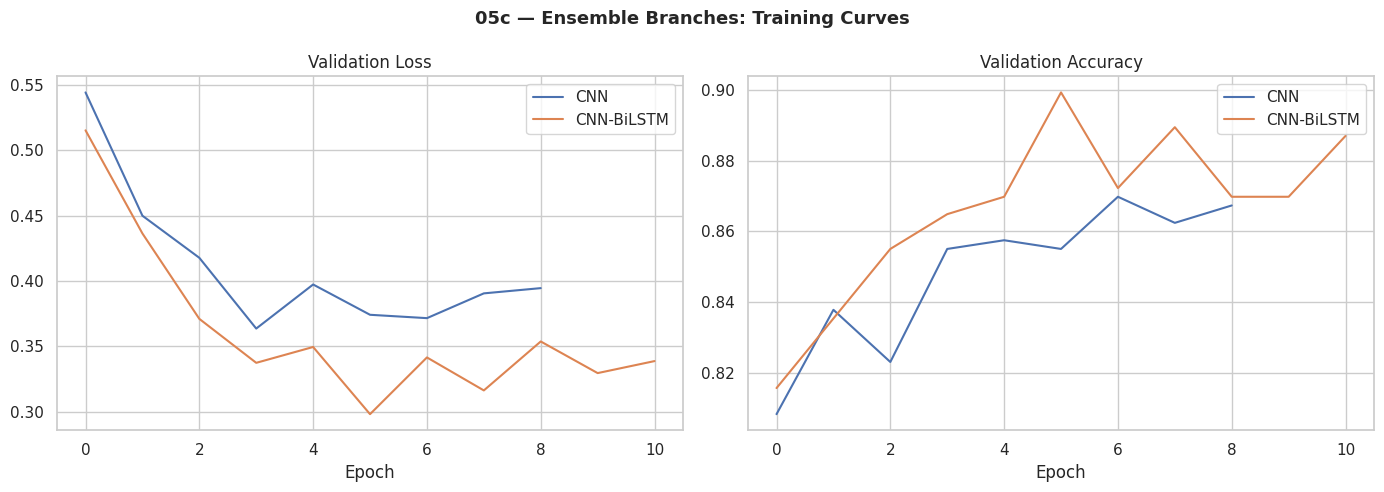

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cnn_history["val_loss"], label="CNN")
axes[0].plot(cnn_bilstm_history["val_loss"], label="CNN-BiLSTM")
axes[0].set_title("Validation Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(cnn_history["val_acc"], label="CNN")
axes[1].plot(cnn_bilstm_history["val_acc"], label="CNN-BiLSTM")
axes[1].set_title("Validation Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()

fig.suptitle("05c — Ensemble Branches: Training Curves", fontsize=13, weight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05c_training_curves.png")
plt.show()

## 9. Test Set Evaluation — Individual Branches and Averaged Ensemble

Both branches' best checkpoints are loaded, and each is evaluated on the test set independently. The **ensemble prediction** is then computed by averaging each branch's softmax probability output for every test example — exactly the "averaging unit" described in Chowdhury et al. (2025)'s Fig. 1 — and evaluated the same way.

In [20]:
cnn_model.load_state_dict(torch.load(CNN_MODEL_PATH, map_location=DEVICE))
cnn_bilstm_model.load_state_dict(torch.load(CNN_BILSTM_MODEL_PATH, map_location=DEVICE))
cnn_model.eval()
cnn_bilstm_model.eval()

cnn_probs_list, cnn_bilstm_probs_list, all_labels = [], [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        cnn_probs = torch.softmax(cnn_model(X_batch), dim=1).cpu().numpy()
        cnn_bilstm_probs = torch.softmax(cnn_bilstm_model(X_batch), dim=1).cpu().numpy()

        cnn_probs_list.append(cnn_probs)
        cnn_bilstm_probs_list.append(cnn_bilstm_probs)
        all_labels.extend(y_batch.numpy())

cnn_probs_all = np.concatenate(cnn_probs_list, axis=0)
cnn_bilstm_probs_all = np.concatenate(cnn_bilstm_probs_list, axis=0)
ensemble_probs_all = (cnn_probs_all + cnn_bilstm_probs_all) / 2.0

all_labels = np.array(all_labels)
cnn_preds = cnn_probs_all.argmax(axis=1)
cnn_bilstm_preds = cnn_bilstm_probs_all.argmax(axis=1)
ensemble_preds = ensemble_probs_all.argmax(axis=1)

print("Predictions computed for: CNN branch, CNN-BiLSTM branch, and the averaged ensemble.")

Predictions computed for: CNN branch, CNN-BiLSTM branch, and the averaged ensemble.


In [21]:
def compute_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    _, _, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    return {
        "accuracy": accuracy, "precision_macro": precision_macro,
        "recall_macro": recall_macro, "f1_macro": f1_macro, "f1_weighted": f1_weighted,
    }


cnn_metrics = compute_metrics(all_labels, cnn_preds)
cnn_bilstm_metrics = compute_metrics(all_labels, cnn_bilstm_preds)
ensemble_metrics = compute_metrics(all_labels, ensemble_preds)

comparison_df = pd.DataFrame(
    {"CNN": cnn_metrics, "CNN-BiLSTM": cnn_bilstm_metrics, "Ensemble (averaged)": ensemble_metrics}
).T
print("Test set comparison — CNN branch vs. CNN-BiLSTM branch vs. averaged ensemble:\n")
display(comparison_df.round(4))

if ensemble_metrics["f1_macro"] >= max(cnn_metrics["f1_macro"], cnn_bilstm_metrics["f1_macro"]):
    print("\n\u2705 The averaged ensemble matched or outperformed both individual branches on macro-F1, "
          "consistent with Chowdhury et al. (2025)'s finding that ensembling helps.")
else:
    print("\n\u26a0\ufe0f  The ensemble did NOT outperform the best individual branch on this dataset. "
          "Report this honestly — it's a valid, useful finding, not a failure of the notebook.")

Test set comparison — CNN branch vs. CNN-BiLSTM branch vs. averaged ensemble:



,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
CNN,0.8771,0.8752,0.8737,0.8739,0.8762
CNN-BiLSTM,0.8943,0.8977,0.8910,0.8926,0.8948
Ensemble (averaged),0.8894,0.8899,0.8870,0.8874,0.8893



⚠️  The ensemble did NOT outperform the best individual branch on this dataset. Report this honestly — it's a valid, useful finding, not a failure of the notebook.


In [22]:
print("Ensemble — full classification report:\n")
print(classification_report(
    all_labels, ensemble_preds, target_names=[idx_to_label[i] for i in range(NUM_CLASSES)], zero_division=0
))

Ensemble — full classification report:

              precision    recall  f1-score   support

       happy       0.81      0.88      0.84        66
         sad       0.88      0.86      0.87        65
       angry       0.90      0.95      0.93        65
        fear       0.90      0.85      0.87        65
     neutral       0.93      0.95      0.94        81
    surprise       0.93      0.83      0.88        65

    accuracy                           0.89       407
   macro avg       0.89      0.89      0.89       407
weighted avg       0.89      0.89      0.89       407



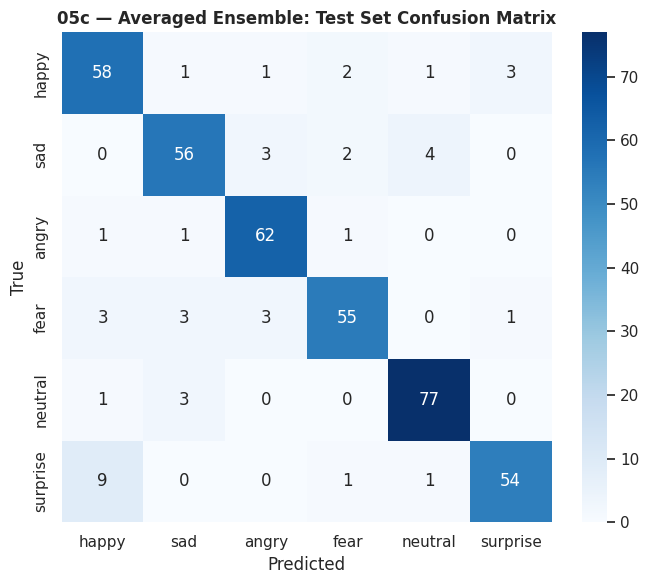

In [23]:
cm = confusion_matrix(all_labels, ensemble_preds)
labels_ordered = [idx_to_label[i] for i in range(NUM_CLASSES)]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_ordered, yticklabels=labels_ordered, ax=ax)
ax.set_title("05c — Averaged Ensemble: Test Set Confusion Matrix", fontsize=12, weight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05c_confusion_matrix.png")
plt.show()

## 10. Save Model Metadata

In [24]:
def get_git_commit_hash() -> str:
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "HEAD"], cwd=PROJECT_ROOT, stderr=subprocess.DEVNULL
        ).decode().strip()
    except Exception:
        return "unknown"


model_metadata = {
    "model_name": "ensemble",
    "architecture": "Averaging ensemble of EnsembleCNN and EnsembleCNNBiLSTM (Chowdhury et al. 2025, Table 2)",
    "literature_basis": "Chowdhury, Ramanna & Kotecha (2025), Scientific Reports",
    "input_length": int(D),
    "num_classes": NUM_CLASSES,
    "label_to_idx": label_to_idx,
    "scaler_path": str(SCALER_PATH.relative_to(PROJECT_ROOT)),
    "cnn_branch_path": str(CNN_MODEL_PATH.relative_to(PROJECT_ROOT)),
    "cnn_bilstm_branch_path": str(CNN_BILSTM_MODEL_PATH.relative_to(PROJECT_ROOT)),
    "hyperparameters": {
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "dropout": DROPOUT_RATE,
        "lstm_hidden_size": LSTM_HIDDEN_SIZE,
        "max_epochs": MAX_EPOCHS,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "lr_scheduler_patience": LR_SCHEDULER_PATIENCE,
        "lr_min": LR_MIN,
    },
    "training": {
        "cnn_branch_best_epoch": cnn_best_epoch,
        "cnn_bilstm_branch_best_epoch": cnn_bilstm_best_epoch,
        "cnn_branch_duration_seconds": round(cnn_duration, 1),
        "cnn_bilstm_branch_duration_seconds": round(cnn_bilstm_duration, 1),
        "device": str(DEVICE),
        "environment": "Google Colab" if IN_COLAB else "local",
    },
    "test_metrics": {
        "cnn_branch": cnn_metrics,
        "cnn_bilstm_branch": cnn_bilstm_metrics,
        "ensemble": ensemble_metrics,
    },
    "git_commit": get_git_commit_hash(),
    "trained_at_utc": datetime.now(timezone.utc).isoformat(),
}

with open(MODEL_METADATA_PATH, "w") as f:
    json.dump(model_metadata, f, indent=2)

logger.info("Saved model metadata to %s", MODEL_METADATA_PATH)
print(f"Saved: {CNN_MODEL_PATH}")
print(f"Saved: {CNN_BILSTM_MODEL_PATH}")
print(f"Saved: {SCALER_PATH}")
print(f"Saved: {MODEL_METADATA_PATH}")

Saved: /content/drive/MyDrive/emotion-ai-companion-research/models/h1/ensemble_cnn_branch.pt
Saved: /content/drive/MyDrive/emotion-ai-companion-research/models/h1/ensemble_cnn_bilstm_branch.pt
Saved: /content/drive/MyDrive/emotion-ai-companion-research/models/h1/ensemble_scaler.pkl
Saved: /content/drive/MyDrive/emotion-ai-companion-research/models/h1/ensemble_metadata.json


## 11. Append to Shared Experiment Log

Three rows are appended: the two individual branches (useful diagnostic detail, matching the comparison Chowdhury et al. themselves report) and the **ensemble**, which is this notebook's official H1 candidate entry for `06_model_selection.ipynb`.

In [25]:
base_row = {
    "timestamp_utc": model_metadata["trained_at_utc"],
    "git_commit": model_metadata["git_commit"],
    "environment": model_metadata["training"]["environment"],
}

rows = [
    {**base_row, "notebook": "05c_model_ensemble", "model_name": "ensemble_cnn_branch",
     "test_accuracy": cnn_metrics["accuracy"], "test_precision_macro": cnn_metrics["precision_macro"],
     "test_recall_macro": cnn_metrics["recall_macro"], "test_f1_macro": cnn_metrics["f1_macro"],
     "test_f1_weighted": cnn_metrics["f1_weighted"], "best_epoch": cnn_best_epoch,
     "epochs_run": len(cnn_history["train_loss"]), "training_duration_seconds": round(cnn_duration, 1),
     "model_metadata_path": str(MODEL_METADATA_PATH.relative_to(PROJECT_ROOT)),
     "note": "Individual branch — diagnostic only, not the official H1 candidate"},

    {**base_row, "notebook": "05c_model_ensemble", "model_name": "ensemble_cnn_bilstm_branch",
     "test_accuracy": cnn_bilstm_metrics["accuracy"], "test_precision_macro": cnn_bilstm_metrics["precision_macro"],
     "test_recall_macro": cnn_bilstm_metrics["recall_macro"], "test_f1_macro": cnn_bilstm_metrics["f1_macro"],
     "test_f1_weighted": cnn_bilstm_metrics["f1_weighted"], "best_epoch": cnn_bilstm_best_epoch,
     "epochs_run": len(cnn_bilstm_history["train_loss"]), "training_duration_seconds": round(cnn_bilstm_duration, 1),
     "model_metadata_path": str(MODEL_METADATA_PATH.relative_to(PROJECT_ROOT)),
     "note": "Individual branch — diagnostic only, not the official H1 candidate"},

    {**base_row, "notebook": "05c_model_ensemble", "model_name": "ensemble",
     "test_accuracy": ensemble_metrics["accuracy"], "test_precision_macro": ensemble_metrics["precision_macro"],
     "test_recall_macro": ensemble_metrics["recall_macro"], "test_f1_macro": ensemble_metrics["f1_macro"],
     "test_f1_weighted": ensemble_metrics["f1_weighted"], "best_epoch": None,
     "epochs_run": None, "training_duration_seconds": round(cnn_duration + cnn_bilstm_duration, 1),
     "model_metadata_path": str(MODEL_METADATA_PATH.relative_to(PROJECT_ROOT)),
     "note": "OFFICIAL H1 candidate 3 of 4 — averaged prediction of both branches above"},
]

experiment_log_df = (
    pd.read_csv(EXPERIMENT_LOG_PATH) if EXPERIMENT_LOG_PATH.exists() else pd.DataFrame()
)
experiment_log_df = pd.concat([experiment_log_df, pd.DataFrame(rows)], ignore_index=True)
experiment_log_df.to_csv(EXPERIMENT_LOG_PATH, index=False)

logger.info("Appended 3 rows to shared experiment log: %s", EXPERIMENT_LOG_PATH)
print(f"Appended 3 rows to: {EXPERIMENT_LOG_PATH}")
experiment_log_df.tail(3)

Appended 3 rows to: /content/drive/MyDrive/emotion-ai-companion-research/reports/experiment_log.csv


,notebook,model_name,timestamp_utc,git_commit,environment,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_f1_weighted,best_epoch,epochs_run,total_parameters,training_duration_seconds,model_metadata_path,note
2,05c_model_ensemble,ensemble_cnn_branch,2026-08-29T11:28:48.348098+00:00,6fc0314f2e2a2a4894ee53662ff03c3810fe1f32,Google Colab,0.877150,0.875174,0.873742,0.873887,0.876187,4.0,9.0,NaN,28.0,models/h1/ensemble_metadata.json,"Individual branch — diagnostic only, not the o..."
3,05c_model_ensemble,ensemble_cnn_bilstm_branch,2026-08-29T11:28:48.348098+00:00,6fc0314f2e2a2a4894ee53662ff03c3810fe1f32,Google Colab,0.894349,0.897715,0.891029,0.892594,0.894756,6.0,11.0,NaN,35.6,models/h1/ensemble_metadata.json,"Individual branch — diagnostic only, not the o..."
4,05c_model_ensemble,ensemble,2026-08-29T11:28:48.348098+00:00,6fc0314f2e2a2a4894ee53662ff03c3810fe1f32,Google Colab,0.889435,0.889915,0.886952,0.887376,0.889292,NaN,NaN,NaN,63.7,models/h1/ensemble_metadata.json,OFFICIAL H1 candidate 3 of 4 — averaged predic...


## 12. Final Sanity Check — Reload and Verify

In [26]:
reload_cnn = EnsembleCNN(num_classes=NUM_CLASSES, input_length=D).to(DEVICE)
reload_cnn.load_state_dict(torch.load(CNN_MODEL_PATH, map_location=DEVICE))
reload_cnn.eval()

reload_cnn_bilstm = EnsembleCNNBiLSTM(num_classes=NUM_CLASSES, input_length=D).to(DEVICE)
reload_cnn_bilstm.load_state_dict(torch.load(CNN_BILSTM_MODEL_PATH, map_location=DEVICE))
reload_cnn_bilstm.eval()

reload_scaler = joblib.load(SCALER_PATH)

sample_X, sample_y = next(iter(test_loader))
with torch.no_grad():
    p1 = torch.softmax(reload_cnn(sample_X.to(DEVICE)), dim=1)
    p2 = torch.softmax(reload_cnn_bilstm(sample_X.to(DEVICE)), dim=1)
    reload_ensemble_preds = ((p1 + p2) / 2.0).argmax(dim=1).cpu()

print("\u2705 Both reloaded branches produce correctly-shaped output.")
print("\u2705 Reloaded scaler loads without error.")
print(f"Sample ensemble predictions: {[idx_to_label[p.item()] for p in reload_ensemble_preds[:5]]}")
print(f"Sample true labels:          {[idx_to_label[l.item()] for l in sample_y[:5]]}")

✅ Both reloaded branches produce correctly-shaped output.
✅ Reloaded scaler loads without error.
Sample ensemble predictions: ['angry', 'sad', 'surprise', 'neutral', 'surprise']
Sample true labels:          ['angry', 'sad', 'surprise', 'neutral', 'surprise']


---

## Summary Note — Handoff

*(Fill in the italicized placeholders after your first real run, before committing.)*

### What was done in this notebook

1. Detected the runtime environment (Colab vs. local) and set up `PROJECT_ROOT` accordingly.
2. Loaded Feature Set B and class weights from `04a`; fit and saved a `StandardScaler` on the training split only.
3. Defined two model branches — plain CNN and CNN-BiLSTM — sharing an identical convolutional backbone, matching Chowdhury et al. (2025)'s architecture with dynamically-computed layer dimensions.
4. Trained both branches independently, using identical training procedures.
5. Evaluated each branch individually and the averaged-probability ensemble on the held-out test split, and reported whether ensembling actually helped on this data.
6. Saved both trained models, the scaler, comparison figures, confusion matrix, and full run metadata.
7. Appended three rows to the shared experiment log — two individual branches (diagnostic) and the ensemble (the official H1 candidate).
8. Reloaded both models and the scaler independently and confirmed the ensemble computation reproduces correctly.

### Outputs produced by this notebook (and where to find them)

| Output | Location | Used by |
|---|---|---|
| CNN branch weights | `models/h1/ensemble_cnn_branch.pt` | Required, alongside the CNN-BiLSTM branch, to reproduce the ensemble prediction |
| CNN-BiLSTM branch weights | `models/h1/ensemble_cnn_bilstm_branch.pt` | Same as above |
| Fitted feature scaler | `models/h1/ensemble_scaler.pkl` | Must be applied to any new input before inference with either branch |
| Combined metadata (both branches + ensemble metrics) | `models/h1/ensemble_metadata.json` | `06_model_selection.ipynb`; thesis results section |
| Training curves / confusion matrix figures | `reports/figures/h1_models/05c_*.png` | Thesis results/appendix |
| Shared experiment log (3 rows appended) | `reports/experiment_log.csv` | `06_model_selection.ipynb` — filter to `model_name == "ensemble"` for the official H1 candidate comparison |
| Run log | `reports/logs/05c_model_ensemble.log` | Debugging either branch's training |

### What needs to be done next

- **`05d_model_wav2vec2.ipynb`** — the fourth and final H1 candidate; independent of this notebook.
- Once all four are trained, **`06_model_selection.ipynb`** compares them via `reports/experiment_log.csv`. When filtering this notebook's contribution, use the row where `model_name == "ensemble"` — the two branch rows are informative but are not a separate H1 candidate in their own right.

**Before running `06_model_selection.ipynb`, confirm:**
- All three rows from this notebook appear in `reports/experiment_log.csv`.
- `models/h1/ensemble_cnn_branch.pt`, `ensemble_cnn_bilstm_branch.pt`, `ensemble_scaler.pkl`, and `ensemble_metadata.json` all exist.
- Section 12's reload sanity check printed \u2705 for both branches and the scaler.

### Resources needed for the next step

| Resource | Needed for | Notes |
|---|---|---|
| `reports/experiment_log.csv` | Cross-model comparison table | Filter on `model_name == "ensemble"` for this notebook's official H1 entry |
| `models/h1/ensemble_*.{pt,pkl,json}` | Reproducing the ensemble prediction | **Both** `.pt` files and the `.pkl` scaler are required together — the ensemble cannot be reproduced from only one branch |

### Known issues / things to watch for

- *(Fill in anything discovered during this run — e.g. whether the ensemble actually outperformed both individual branches, matching or contradicting Chowdhury et al.'s own finding; note this either way, it is a valid and useful result regardless of direction.)*

### Run metadata

- **Run by:** *Thrithwaka Preethi Shakya*
- **Date:** *28/08/2026*
- **Environment:** *Colab*
- **CNN branch test accuracy / F1 (macro):** *0.8739*
- **CNN-BiLSTM branch test accuracy / F1 (macro):** *0.8926*
- **Ensemble test accuracy / F1 (macro):** *0.8874*